<a href="https://colab.research.google.com/github/Gavin-Ricks/SBX-PROJECTS/blob/main/sbx_proposal_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA Research Notebook

## Title and Basic Information

**Paper title:** Online vs Offline Schooling and the Effects on Exam Scores


**Author name:** Gavin Ricks

**Date:** July 10th, 2026

### Research Question

**Research Question:** Do students learning online achieve significantly different exam scores than students learning offline?


### Hypothesis

Based on your research question, what do you expect to find? This can be informal, it just needs to be your best guess **before** analyzing the data.

> **Your hypothesis:**
Null – Students using offline learning earn similar exam scores than the students learning online.

>Alternative – Students using offline learning earn significantly higher exam scores than students using online learning.

### Background Research

Background Research

*   Efficiency of Online vs Offline learning – This found that online learning was slightly more efficient for student learning and resulted in slightly better test grades. (Singh et al., 2012, pp. 95–96)
*   Learning Online, Offline, and In-Between  – There were no significant differences in academic performance among students in the face-to-face, online, and blended course formats. Students performed similarly on all three examinations, the research paper, and the overall course grade (Yen et al., 2018, pp. 2147–2149).

*   Online Education, Worldwide Status – Online learning provides several advantages over traditional face-to-face instruction, including greater flexibility, reduced travel time, lower infrastructure costs for institutions, and increased accessibility for working professionals and students in remote locations (Palvia et al., 2018, pp. 233–235).

Gaps Filled: The studies that exist only use smaller datasets and do not meaningfully reflect a significant result; this analysis will address those concerns by using a stronger dataset that is more conclusive.



### Data Source Information


Data Source Information

Source: Course-provided dataset, "Online vs Offline Learning"


Collection method: N/A


Time period: N/A

Sample size: 1,000 student records (500 Offline, 500 Online).


Variables:


*   Learning_Mode (Online/Offline)

*   Subject (English, Math, Science, Programming, History)

*   Study_Hours
*   Retention_Score (40–100)


*   Focus_Level (40–100)


*   Exam_Score (0–100)







Data quality issues:
>No missing values found
Ethical considerations: Minimal, no personally identifiable student information, information is anonymous.

Limitations:
>Source and collection method aren't documented, so it's unclear how closely this reflects real student populations. Subjects are general and could be seen as not specific enough.




## Exploratory Data Analysis (EDA)

### Data Analysis Plan

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Variables:


*   Learning_Mode (independent/grouping variable)
*   Exam_Score (dependent variable)


Relationships:
>Comparison of average Exam_Score between Online and Offline groups. Potentially different subjects as well.

Visualizations:
>boxplot of Exam_Score by Learning_Mode
 histogram of Exam_Score distributions for each group for comparison.

Statistical tests:
>independent-samples t-test comparing Exam_Score between Online and Offline learners

Connection to research question:
>This test directly answers the question in the research question by providing clearly relatable information that can be surmised from the result of the analysis.


### Load and Explore Your Dataset

##### Load Libraries

In [ ]:
# Load and explore the dataset
# You may need more libraries depending on your dataset and analysis needs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

##### Load Dataset

In [ ]:
# Example: Load your dataset
df = pd.read_csv('online_vs_offline_learning_dataset.csv')

In [ ]:
# Offline vs Online Dataset
fn_file_id = '134dhpbYi_zA_kVGxlwO0PSziuW2yWMNP'
fn_url = f'https://drive.google.com/uc?id={fn_file_id}'

fn_df = pd.read_csv(fn_url)

In [ ]:
# Cardiac Arrest dataset
# link: https://drive.google.com/file/d/1yPVFi4AVwy3CysWce36Ls4GuF_nSbkBK/view?usp=sharing
ai_file_id = '1yPVFi4AVwy3CysWce36Ls4GuF_nSbkBK'
ai_url = f'https://drive.google.com/uc?id={ai_file_id}'

ai_df = pd.read_csv(ai_url)

#### Initial Data Exploration

Things you should be checking for:
- Is the data clean?
- What are the datatypes? Are they correct?
- How many rows and columns?
- Descriptive stats?

In [ ]:
# Basic statistics, data types, missing values
# Data quality assessment

# Example: Basic data exploration
# print(df.info())
# print(df.describe())
# print(df.head())
# print(df.shape)

In [ ]:
fn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Learning_Mode    1000 non-null   object 
 1   Subject          1000 non-null   object 
 2   Study_Hours      1000 non-null   float64
 3   Retention_Score  1000 non-null   int64  
 4   Focus_Level      1000 non-null   int64  
 5   Exam_Score       1000 non-null   int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 47.0+ KB


In [ ]:
fn_df.head()

,Learning_Mode,Subject,Study_Hours,Retention_Score,Focus_Level,Exam_Score
0,Offline,English,7.7,51,96,70
1,Offline,English,6.2,90,82,81
2,Online,English,1.2,75,66,71
3,Online,Math,6.5,80,64,77
4,Online,English,5.5,95,58,78


In [ ]:
fn_df.isnull().sum()

,0
Learning_Mode,0
Subject,0
Study_Hours,0
Retention_Score,0
Focus_Level,0
Exam_Score,0


In [ ]:
fn_df.describe()

,Study_Hours,Retention_Score,Focus_Level,Exam_Score
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,4.563500,72.69100,71.261000,71.675000
std,2.000115,17.69827,18.053166,12.984297
min,1.000000,40.00000,40.000000,39.000000
25%,2.800000,58.00000,56.000000,62.000000
50%,4.700000,72.00000,72.000000,72.000000
75%,6.300000,88.00000,87.000000,81.000000
max,8.000000,100.00000,100.000000,100.000000


In [ ]:
# Defining the variables I am interested in
my_var = ['Learning_Mode','Exam_Score']
# Creating my custom data frame
my_df = fn_df[my_var]

#placed_df = df[['Placement' == 'TRUE']]
#notplaced_df = df[['Placement' == 'FALSE']]

# determine if someone is placed are they more likely to have an internship
# likelihood that someone from the placed group has internship
# likelihood that someone from the not placed group has intership
# the average number of student who have internships
# compare them to each other

In [ ]:
my_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Learning_Mode  1000 non-null   object
 1   Exam_Score     1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [ ]:
my_df.head()

,Learning_Mode,Exam_Score
0,Offline,70
1,Offline,81
2,Online,71
3,Online,77
4,Online,78


### Data Visulizations and Analysis

#### Guidelines

Create visualizations that help answer your research question and support your findings. Each figure should be publication-ready for your final paper.

**Required Visualizations:**
1. **Distribution plots** - Show the shape of your key variables
2. **Relationship plots** - Explore connections between variables  
3. **Comparison plots** - Compare groups or categories in your data
4. **Summary visualization** - One key figure that tells your main story

**For each visualization, include:**
- Clear titles and axis labels
- Appropriate colors and formatting
- Caption explaining what the figure shows
- Interpretation of what you observe

**Visualization Guidelines:**
- Save all figures as high-resolution files (.png or .pdf)
- Use consistent color schemes across figures
- Make sure text is readable at publication size
- Each figure should serve a purpose in your analysis

#### Univariate Analysis

**1. Univariate Analysis**
- Create distribution plots for key variables
- Identify outliers and data quality issues
- [code cells for histograms, box plots, etc.]

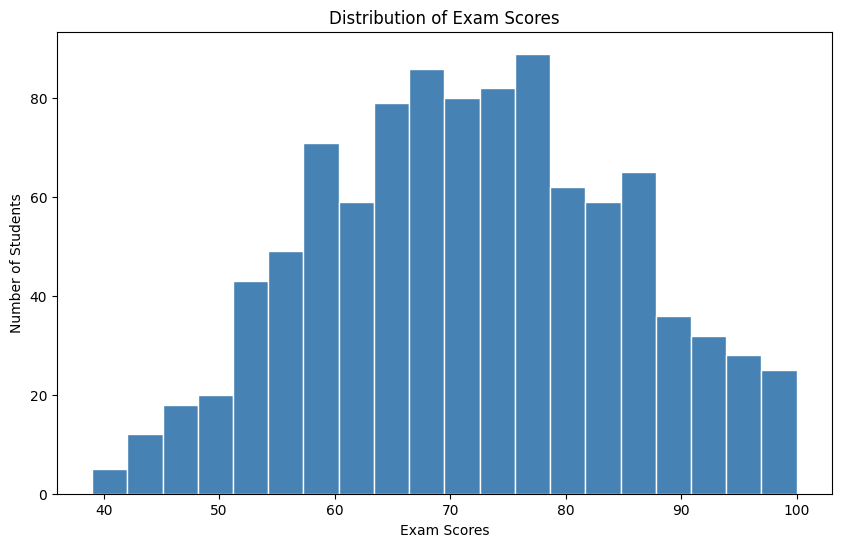

In [ ]:
# Distribution of individual variables
# Outlier detection

#Histograms of all Exam Scores
plt.figure(figsize=(10,6))
plt.hist(df['Exam_Score'], bins = 20, color = "steelblue", edgecolor = "white")
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Scores")
plt.ylabel("Number of Students")
plt.show()

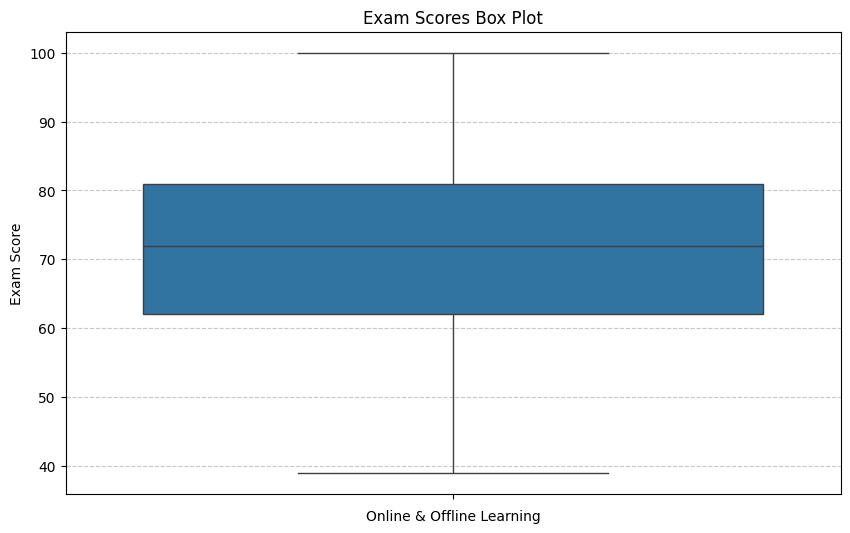

In [ ]:
#Box Plot of Exam Score Data
plt.figure(figsize=(10, 6))
sns.boxplot(y='Exam_Score', data=df)
plt.title('Exam Scores Box Plot')
plt.xlabel('Online & Offline Learning')
plt.ylabel('Exam Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Bivariate Analysis

**2. Bivariate Analysis**
- Explore relationships between variables
- Create scatter plots, correlation matrices
- [code cells for relationship plots]

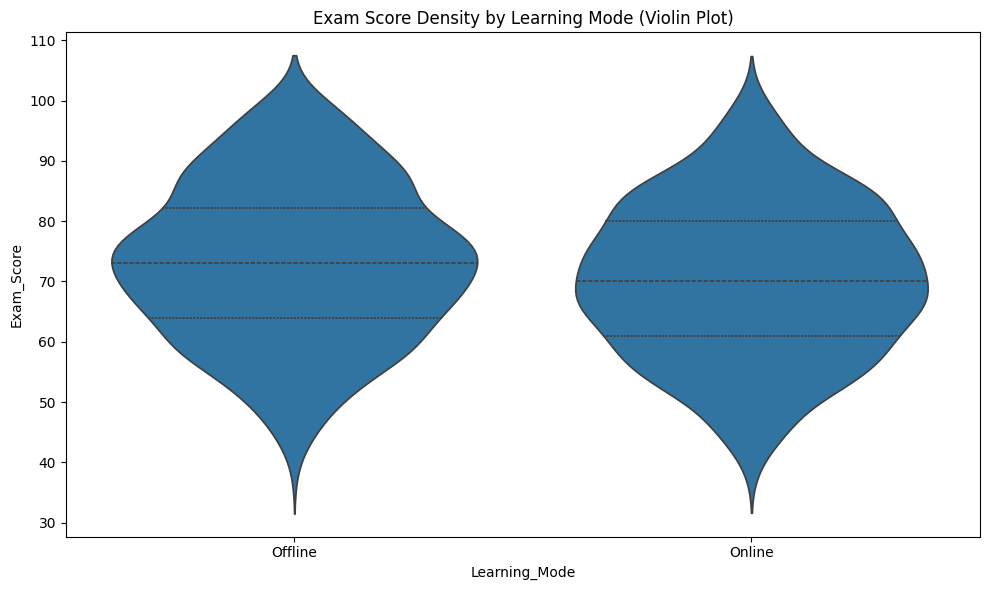

In [ ]:
# Relationships between variables
# Correlation analysis

#Violin Plot for a more specific showcase
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Learning_Mode', y='Exam_Score', inner='quartile')
plt.title('Exam Score Density by Learning Mode (Violin Plot)')

plt.tight_layout()
plt.show()



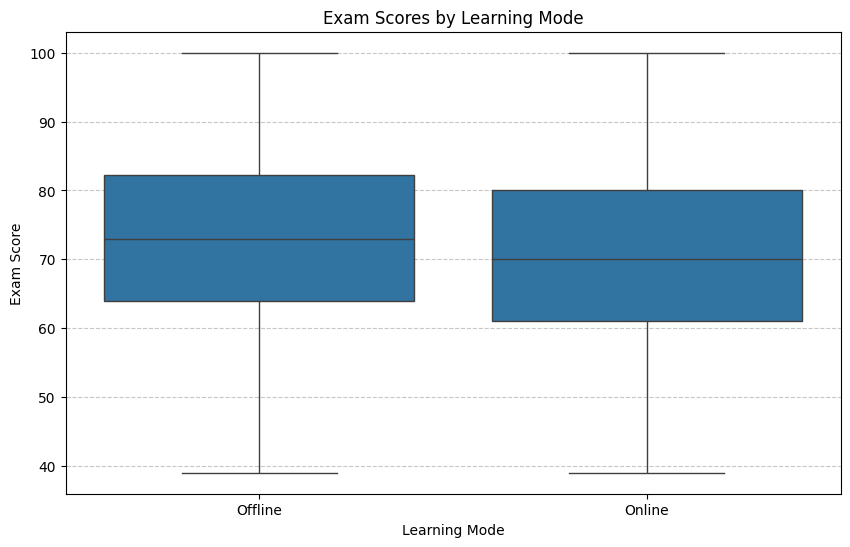

In [ ]:
#Box Plot of Learning Mode Exam Score Data
plt.figure(figsize=(10, 6))
sns.boxplot(x='Learning_Mode', y='Exam_Score', data=df)
plt.title('Exam Scores by Learning Mode')
plt.xlabel('Learning Mode')
plt.ylabel('Exam Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Statistical Testing

**3. Statistical Testing**
- Perform tests relevant to your research question
- Create visualizations to support statistical results
- [code cells for tests and supporting plots]

In [ ]:
# Hypothesis tests relevant to your research question
#T-Test :)
online_scores = df.loc[df['Learning_Mode'] == 'Online', 'Exam_Score']
offline_scores = df.loc[df['Learning_Mode'] == 'Offline', 'Exam_Score']

print(f"Online Scores Mean: {round(online_scores.mean(),2)}")
print(f"Offline Scores Mean: {round(offline_scores.mean(),2)}")

t_stat, p_value = stats.ttest_ind(online_scores,offline_scores,equal_var=True)

print(f"\nt-statistic = {t_stat:.3f}")
print(f"p-value     = {p_value:.5f}")

if p_value < 0.05:
    print("Result: statistically significant, we reject the null hypothesis.")
else:
    print("Result: not statistically significant, we fail to reject the null hypothesis.")



Online Scores Mean: 70.21
Offline Scores Mean: 73.14

t-statistic = -3.579
p-value     = 0.00036
Result: statistically significant, we reject the null hypothesis.


## Results Summary

### Key Findings

The T-Test was done to compare the exam scores of the Online and Offline students. The results show:

*   **Online Scores Mean:** 70.21
*   **Offline Scores Mean:** 73.14

*   **t-statistic:** -3.579
*   **p-value:** 0.00036

Since the p-value (0.00036) is less than the significance p number p > 0.05 this shows that this embraces the alternative hypothesis. This indicates a statistically significant difference in exam scores between online and offline learners.

### Interpretation

Students learning offline achieved significantly higher exam scores (mean = 73.14) compared to students learning online (mean = 70.21). This provides evidence to support the alternative hypothesis. This shows that learning mode has a significant impact on exam scores

## Discussion Notes

Use this section to develop your discussion content.

#### 1. Interpretation:

 - What do your results mean in practical terms?

 > Our results show us that offline learning is statistically better than offline learning for schooling. The means of offline learning vs online learning is statistically significant
- How do they answer your research question?
 > This supports our alternative hypothesis that: Students using offline learning earn significantly higher exam scores than students who use online.
 - Are there alternative explanations?
  > This analysis also supports the idea that whatever offline curriculum is used is superior than whatever online cirriculum that was being used.

#### 2. Comparison with Literature

The background research does not entirely support this finding. The research I did found the difference between performance in schools using offline vs online learning was negligible. This was mostly due to the sample size not being large enough.


#### 3. Limitations

Because this data is synthetic this finding can possibly be misleading due to the data being artificially made. The school curriculum varies significantly from state to state in the United States. Some states have more liberal policies of education, while some are more conservative, this could also have an effect on the exam scores.


#### 4. Implications

- What are the practical implications of your findings?
 > My findings imply that offline learning still reings supreme and should still be standard in all schools.
- Who should care about these results?
 > Schools and the DOE (Department of Education) should use this data to further push for offline learning.
- What should be done based on these findings?
 > This should influence how schools decide on their schooling. Since this analysis's results are so clear, it is imperative that schools implement more offline learning methods.


#### 5. Future Discussion

- What questions remain unanswered?
 > What type of learning curriculum is taught for these online classes alongisde the offline classes?
- What additional data would be helpful?
 > It would help to see what type of learning cirriculum these classes/schools are using for the data to ensure that the cirriculum method is not the reason for the lower scores.
- What methods could improve on this analysis?
 > Information on location and demographics of the students could help greatly with narrowing down the possible variables that have not been accounted for in the dataset.

## Conclusion Notes

**Write a concise summary of your main findings and their significance.**

We aimed to answer the question of if students earned significantly different exam scores based on their learning method. We then found that offline learning yielded statistically significantly higher exam scores than online learning. For future research into this topic, I suggest diving deeper into the politics of states and their curriculum, and how that affects exam scores for students.


## Abstract Draft

This analysis tests whether Offline vs Online learning directly results in differing exam scores.My research question was: Do students learning online achieve significantly different exam scores than students learning offline? The data I had was a class provided dataset called “Online_vs_Offline_Learning”. The method used in this study was to organize the dataset by the exam scores variables and the learning method variables, then perform the appropriate tests. I used a t-test to compare two and found that the means are statistically significant, which fails the null hypothesis. This shows that there is a significant difference in offline vs online learning in favor of offline learning.